In [1]:
import torch
from torch import nn, optim
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, silhouette_score
from sklearn.decomposition import PCA
from scipy.stats import chi2
from sklearn.mixture import GaussianMixture

# Classificador

In [2]:
def matriz_conf(y_true, y_pred, labels):
    total_labels = labels
    print(total_labels)
    cm = np.zeros((len(total_labels),len(total_labels)), dtype=int)
    for i in range(len(y_true)):
        cm[y_true[i]][y_pred[i]] += 1
    
    cm = pd.DataFrame(cm, columns=total_labels, index=total_labels)

    cm_transp = pd.DataFrame(np.transpose(cm.to_numpy()), columns=total_labels, index=total_labels)

    for c in cm_transp.columns:
        cm_transp[c] = cm_transp[c]/cm_transp[c].sum()

    cm_porcento = pd.DataFrame(np.transpose(cm_transp.to_numpy()), columns=total_labels, index=total_labels)

    return cm, cm_porcento

def acc(cm, hidden_classes):
    cm_transp = pd.DataFrame(np.transpose(cm.dropna().to_numpy()), columns=cm.columns, index=cm.columns)
    acc = 0
    total = 0
    for c in cm_transp.columns:
        if c not in hidden_classes:
            acc += cm_transp[c][c]
        else:
            acc += cm_transp[c][-1]
        total += cm_transp[c].sum()
    return acc/total

# Calcula CM para todos

In [3]:
filenames = ['0_2','0_3','0_4','0_5','2_3','2_4','2_5','3_4','3_5','4_5']

labels_str = ['DDoS', 'Benign', 'DoS', 'BruteForce', 'Bot', 'Web']

filenames

pd.set_option('future.no_silent_downcasting', True)

0_2


Label
1    514148
3    243806
4    183163
5       596
Name: count, dtype: int64

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


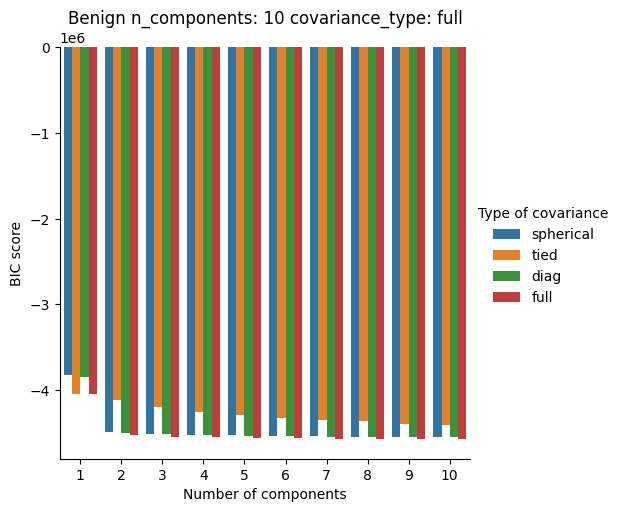

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 9 covariance_type: tied


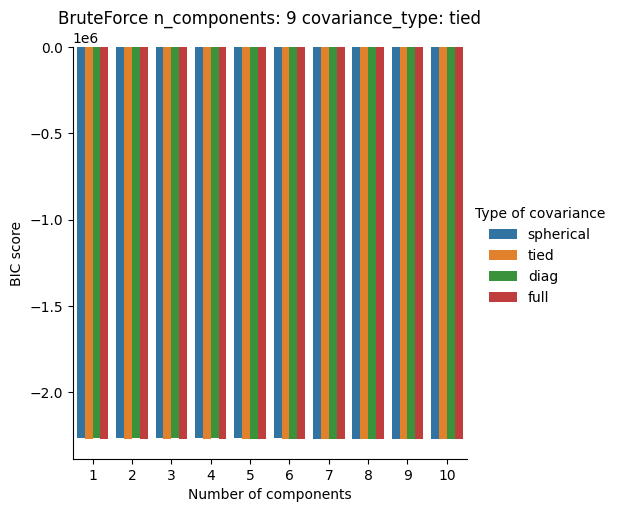

Tipo: 4 = Bot
Melhor modelo: n_componentes: 9 covariance_type: full


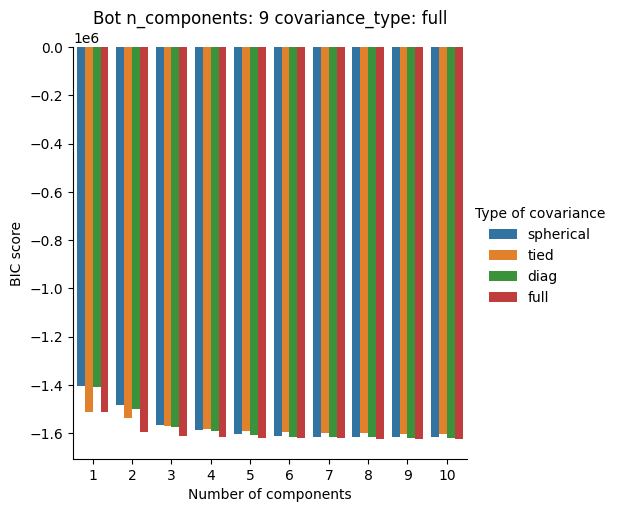

Tipo: 5 = Web
Melhor modelo: n_componentes: 7 covariance_type: spherical


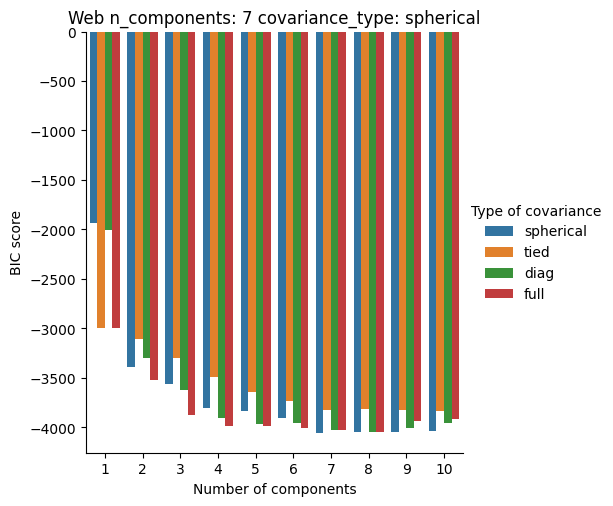

,0,1,2,3,4,5
0,NaN,19.878427,NaN,-143.775505,9.409316,8.805117
1,NaN,15.201074,NaN,-212.228610,9.618085,12.365238
2,NaN,22.886147,NaN,-102.733703,12.719952,9.156154
3,NaN,20.723793,NaN,-84.112485,12.246074,9.284773
4,NaN,10.899625,NaN,-158.194749,6.755134,8.856703
...,...,...,...,...,...,...
649942,NaN,23.173915,NaN,-117.251689,13.018465,9.291691
649943,NaN,10.812998,NaN,-167.498779,6.706420,8.641299
649944,NaN,11.046001,NaN,-163.430629,6.796055,8.744624
649945,NaN,-0.708698,NaN,23.443059,-47.266002,7.134312


0_3


Label
1    514148
2    329224
4    183163
5       596
Name: count, dtype: int64

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


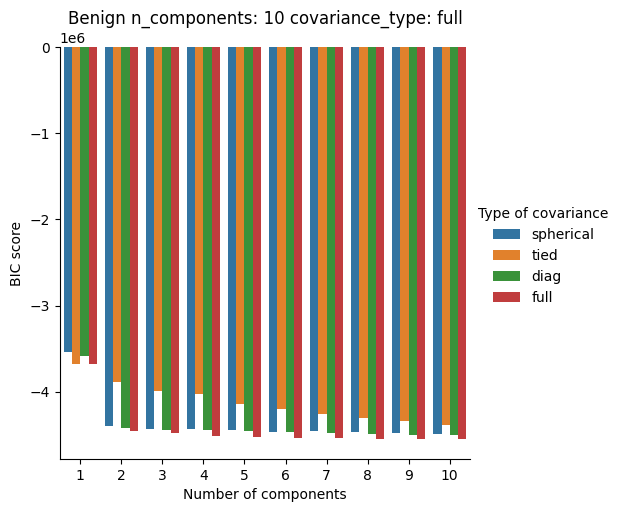

Tipo: 2 = DoS
Melhor modelo: n_componentes: 8 covariance_type: tied


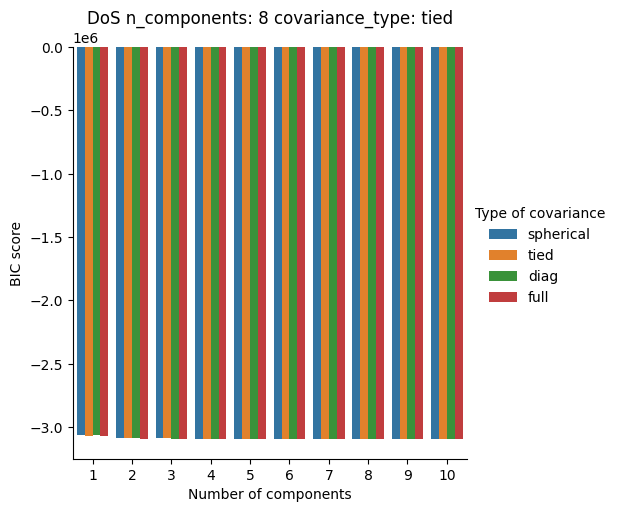

Tipo: 4 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


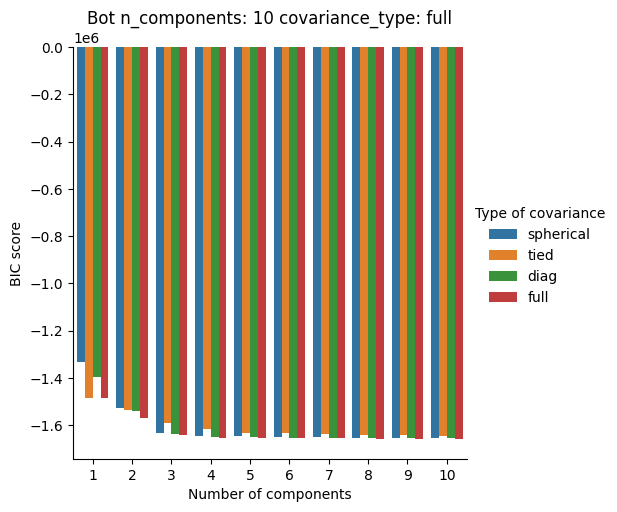

Tipo: 5 = Web
Melhor modelo: n_componentes: 10 covariance_type: spherical


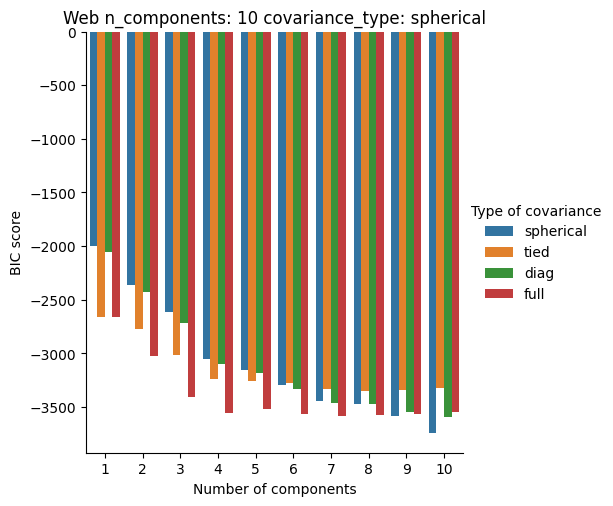

,0,1,2,3,4,5
0,NaN,15.938691,-34.898436,NaN,10.816854,10.030172
1,NaN,15.596507,-163.541484,NaN,10.076495,11.367880
2,NaN,22.686005,-138.140137,NaN,12.874298,12.013648
3,NaN,22.907157,-118.385014,NaN,12.852426,11.741339
4,NaN,17.171635,-50.436381,NaN,11.817175,10.526111
...,...,...,...,...,...,...
649942,NaN,22.976893,-124.958197,NaN,12.789583,12.028919
649943,NaN,17.248710,-51.498375,NaN,11.874945,10.551582
649944,NaN,17.296250,-51.720865,NaN,11.889044,10.567399
649945,NaN,12.287158,6.455155,NaN,3.822109,6.903681


0_4


Label
1    514148
2    329224
3    243806
5       596
Name: count, dtype: int64

Tipo: 1 = Benign
Melhor modelo: n_componentes: 6 covariance_type: full


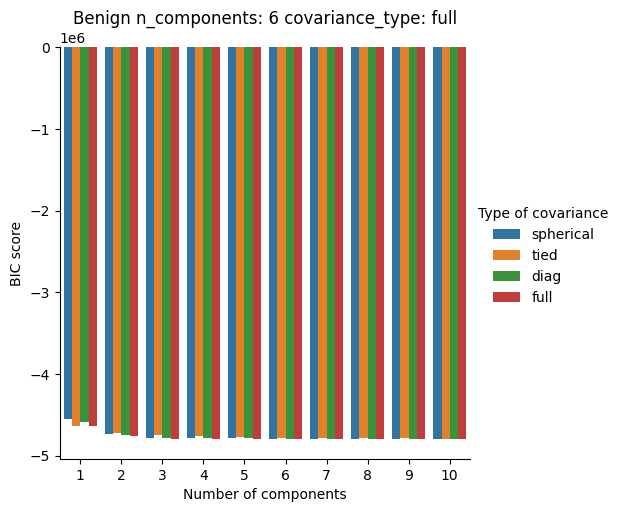

Tipo: 2 = DoS
Melhor modelo: n_componentes: 3 covariance_type: diag


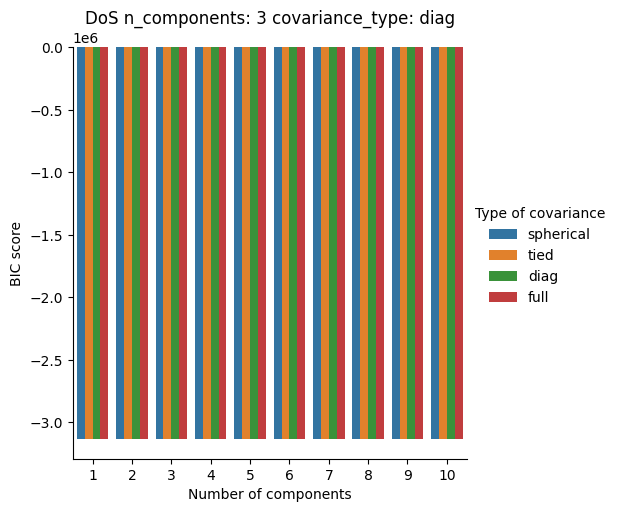

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 1 covariance_type: full


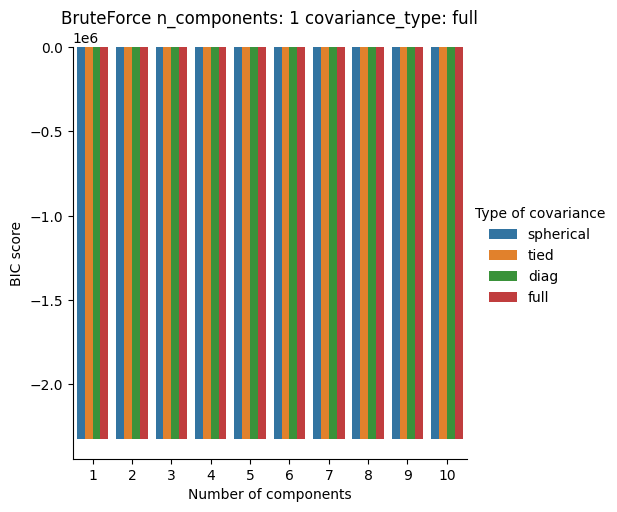

Tipo: 5 = Web
Melhor modelo: n_componentes: 4 covariance_type: spherical


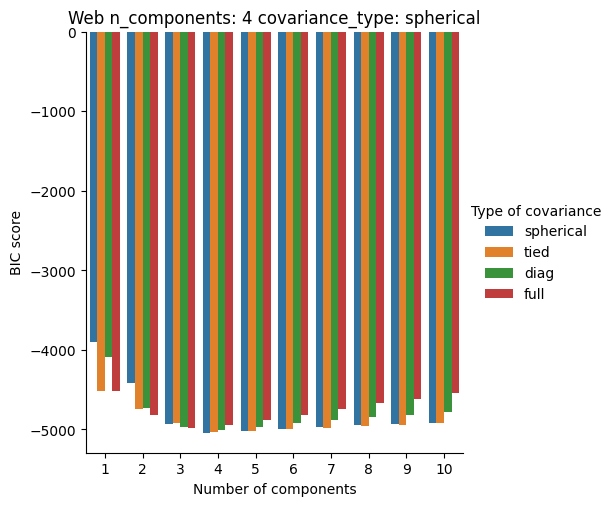

,0,1,2,3,4,5
0,NaN,15.914181,5.342527,-27.613083,NaN,11.475447
1,NaN,23.397496,6.928727,-27.643345,NaN,14.440704
2,NaN,23.427967,7.091543,-27.060980,NaN,14.429699
3,NaN,23.485287,7.713064,-24.472404,NaN,14.382667
4,NaN,17.425880,13.157939,-12.146662,NaN,10.245107
...,...,...,...,...,...,...
649942,NaN,23.658832,6.300384,-29.050970,NaN,15.054827
649943,NaN,17.050393,13.141575,-13.017743,NaN,10.128070
649944,NaN,17.249636,13.124634,-12.837633,NaN,10.212838
649945,NaN,6.338531,1.762166,23.871531,NaN,-1.275231


0_5


Label
1    514148
2    329224
3    243806
4    183163
Name: count, dtype: int64

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


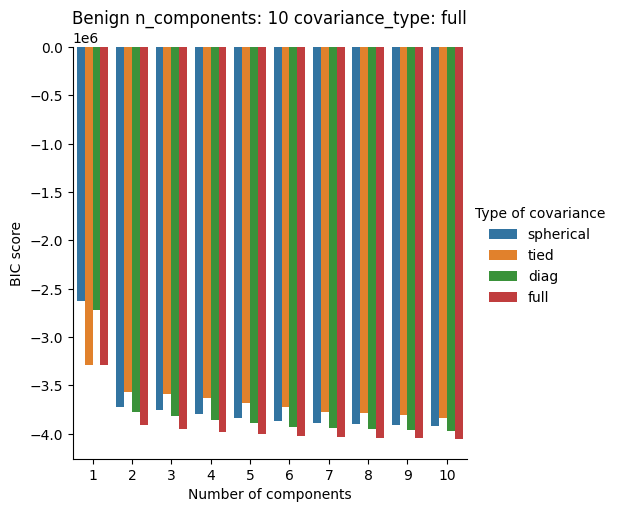

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


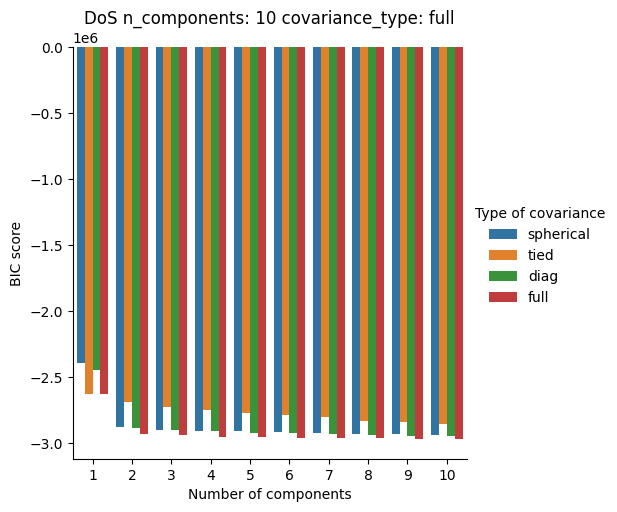

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 9 covariance_type: full


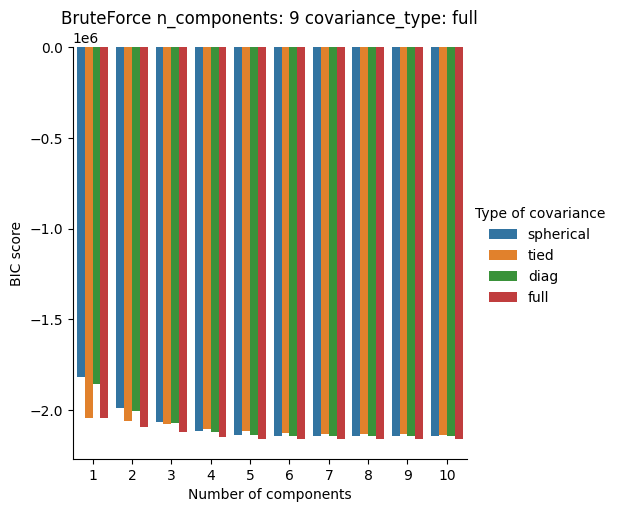

Tipo: 4 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


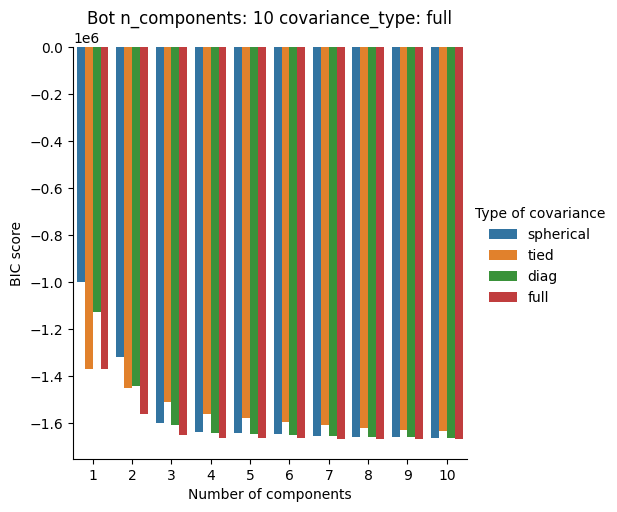

,0,1,2,3,4,5
0,NaN,10.110470,-28.801489,-46.039782,-92.858239,NaN
1,NaN,12.502871,-74.225557,-322.762857,2.790234,NaN
2,NaN,20.110123,-64.355864,-251.347795,13.941024,NaN
3,NaN,13.969394,-35.269337,-136.670243,-10.483384,NaN
4,NaN,9.404046,-29.502986,-67.572803,-58.472250,NaN
...,...,...,...,...,...,...
649942,NaN,21.645036,-57.828222,-220.706964,12.179611,NaN
649943,NaN,8.971834,-26.934407,-63.432660,-72.940958,NaN
649944,NaN,8.982106,-27.357410,-65.113078,-71.896706,NaN
649945,NaN,4.415753,-52.463792,22.354290,-370.317938,NaN


2_3


Label
0    808919
1    514148
4    183163
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 7 covariance_type: full


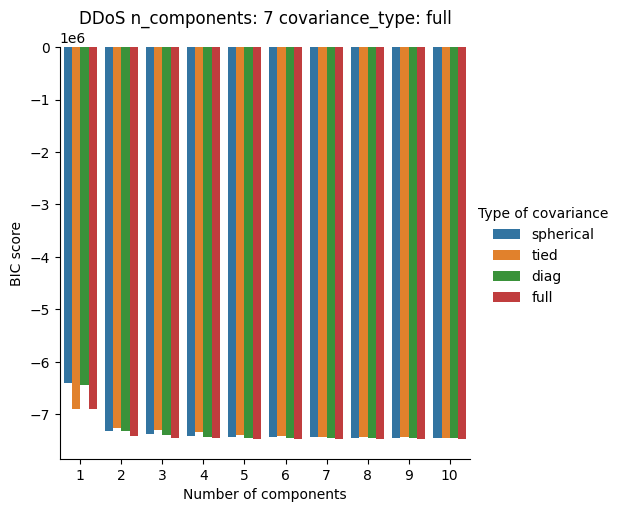

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


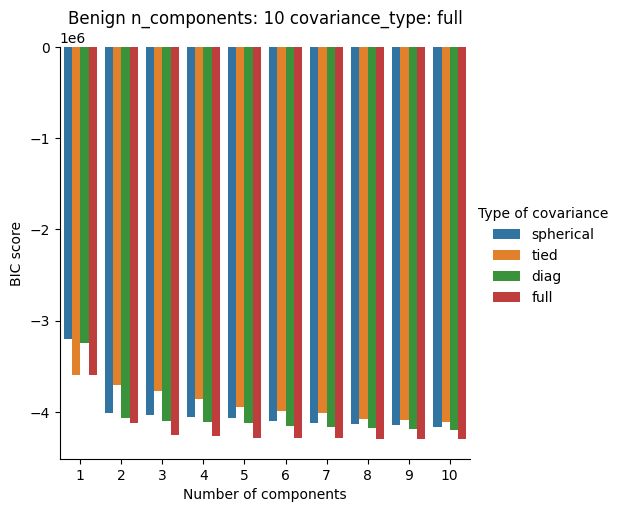

Tipo: 4 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


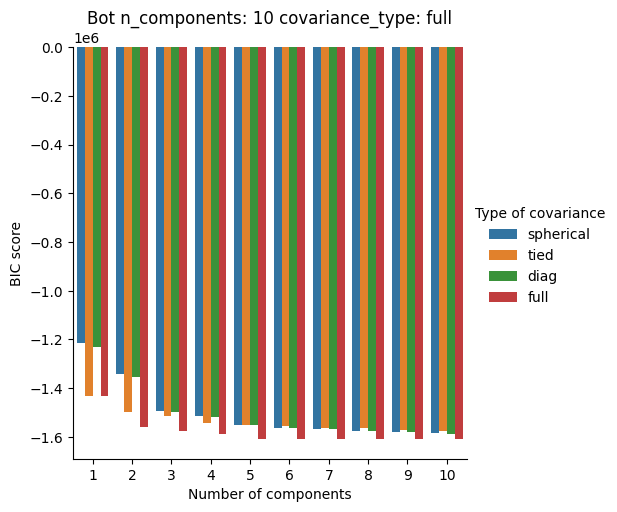

Tipo: 5 = Web
Melhor modelo: n_componentes: 6 covariance_type: full


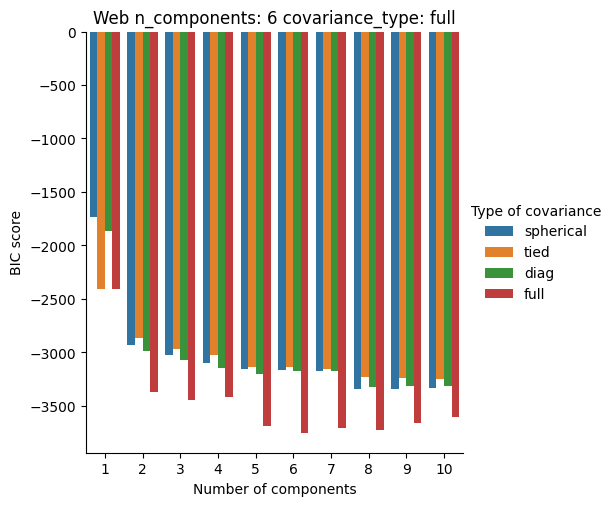

,0,1,2,3,4,5
0,23.551626,9.066707,NaN,NaN,2.363116,4.631023
1,23.490769,8.995761,NaN,NaN,2.201719,4.824523
2,10.352045,16.760216,NaN,NaN,10.849470,10.122706
3,9.958885,16.808344,NaN,NaN,10.129069,9.524881
4,23.373353,9.199992,NaN,NaN,2.978994,5.232836
...,...,...,...,...,...,...
649942,10.427296,22.386409,NaN,NaN,11.467918,10.664294
649943,23.144866,9.273331,NaN,NaN,3.393007,5.274866
649944,23.278750,9.231791,NaN,NaN,3.217800,5.241636
649945,-33.881471,3.420920,NaN,NaN,-29.399067,13.863852


2_4


Label
0    808919
1    514148
3    243806
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 5 covariance_type: full


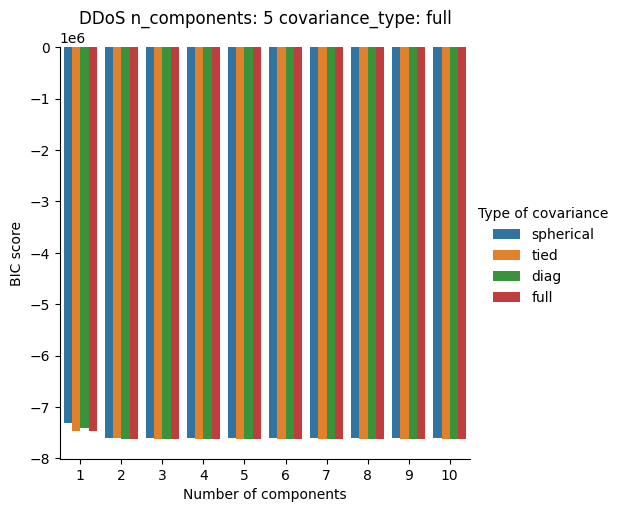

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


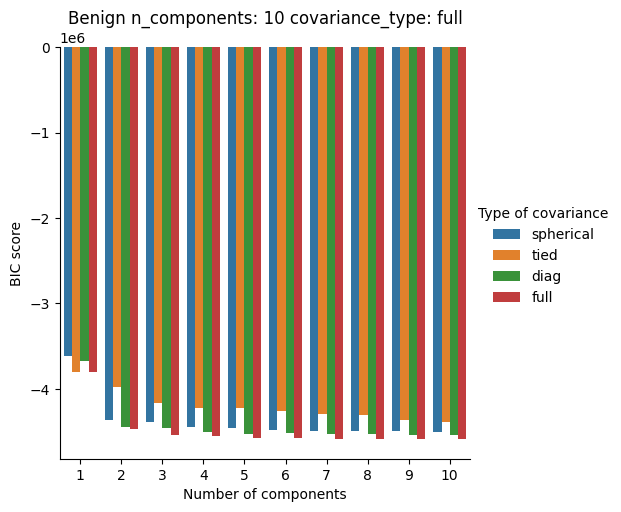

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 10 covariance_type: full


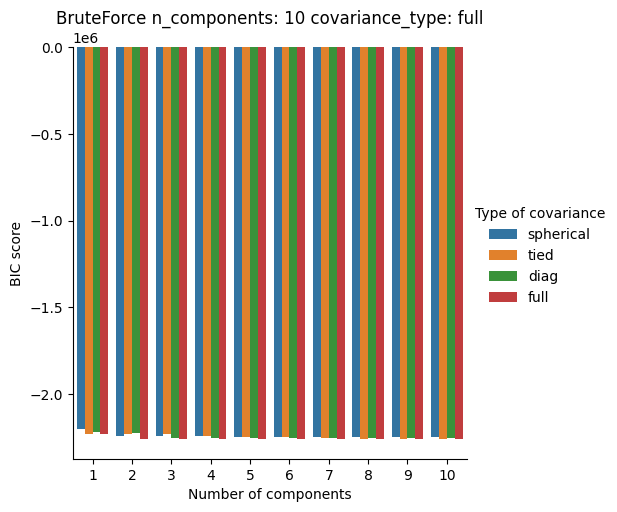

Tipo: 5 = Web
Melhor modelo: n_componentes: 10 covariance_type: spherical


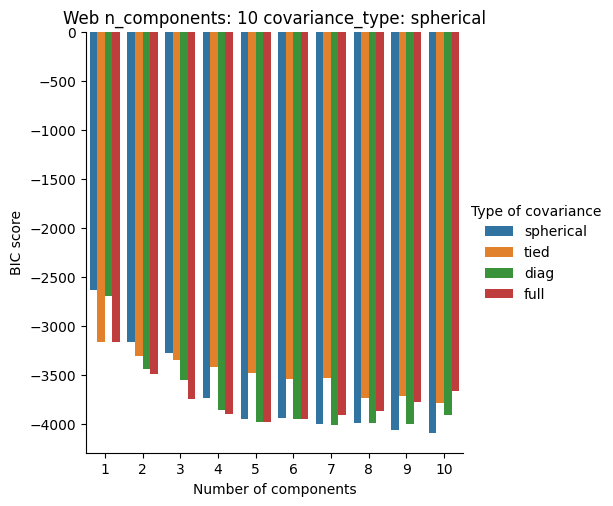

,0,1,2,3,4,5
0,23.751200,15.126021,NaN,5.869000,NaN,14.498591
1,23.724458,15.106072,NaN,5.865254,NaN,14.408597
2,15.191208,22.713620,NaN,-7.870707,NaN,5.849897
3,15.434258,20.869781,NaN,-5.600518,NaN,5.306582
4,23.564801,14.785868,NaN,6.071667,NaN,14.182801
...,...,...,...,...,...,...
649942,15.160417,22.919881,NaN,-7.866244,NaN,5.901983
649943,23.484884,14.711472,NaN,6.099065,NaN,14.062774
649944,23.526016,14.745273,NaN,6.083095,NaN,14.120919
649945,-825.730052,11.029058,NaN,23.323763,NaN,-8.887802


2_5


Label
0    808919
1    514148
3    243806
4    183163
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


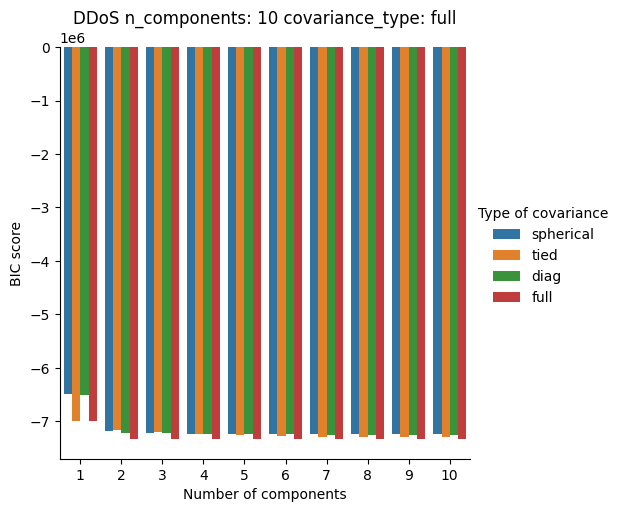

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


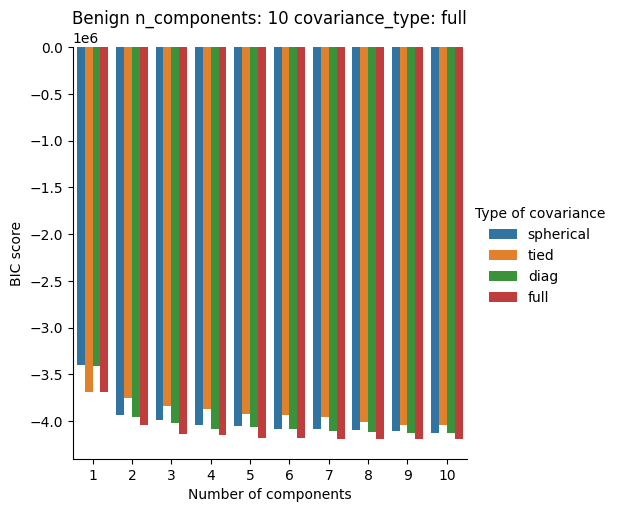

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 4 covariance_type: full


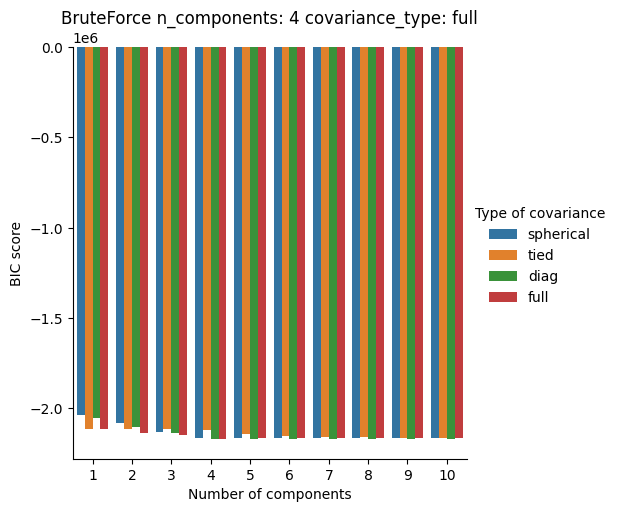

Tipo: 4 = Bot
Melhor modelo: n_componentes: 9 covariance_type: full


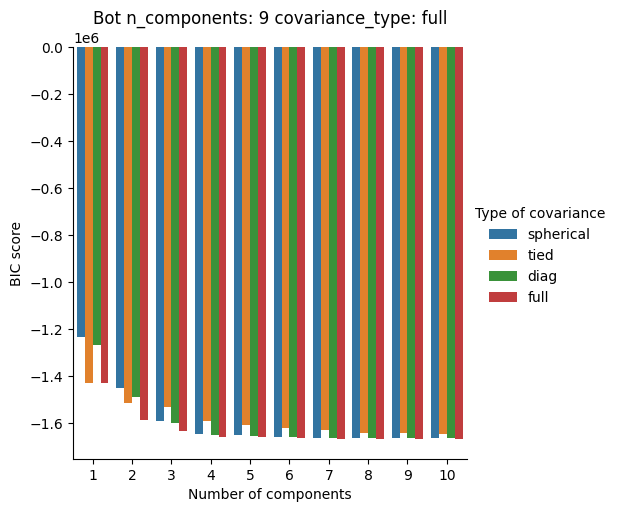

,0,1,2,3,4,5
0,23.009076,14.473703,NaN,-159.643777,9.660883,NaN
1,22.271860,15.463576,NaN,-140.268379,10.181390,NaN
2,6.973355,18.965236,NaN,-9.275115,12.787427,NaN
3,-7.339115,11.949136,NaN,-38.458649,-5.776291,NaN
4,22.747049,13.730486,NaN,-162.105680,7.650597,NaN
...,...,...,...,...,...,...
649942,4.188891,21.845570,NaN,-10.711901,14.783677,NaN
649943,22.523228,14.260322,NaN,-158.686390,7.280741,NaN
649944,22.607744,14.206846,NaN,-159.317881,7.395734,NaN
649945,-2188.355951,7.195467,NaN,22.588882,-1443.858199,NaN


3_4


Label
0    808919
1    514148
2    329224
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


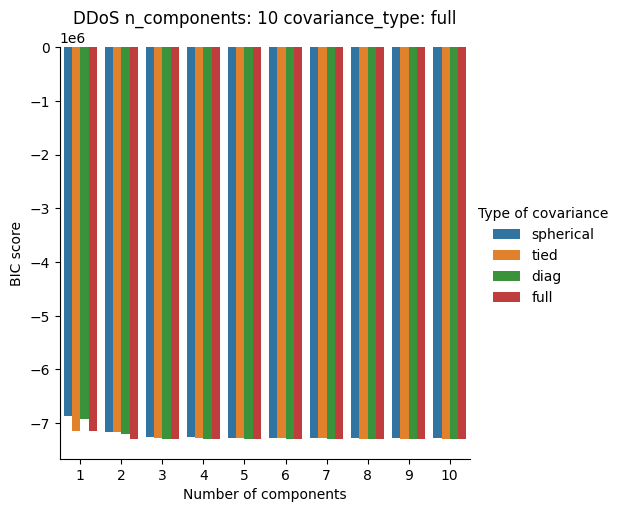

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


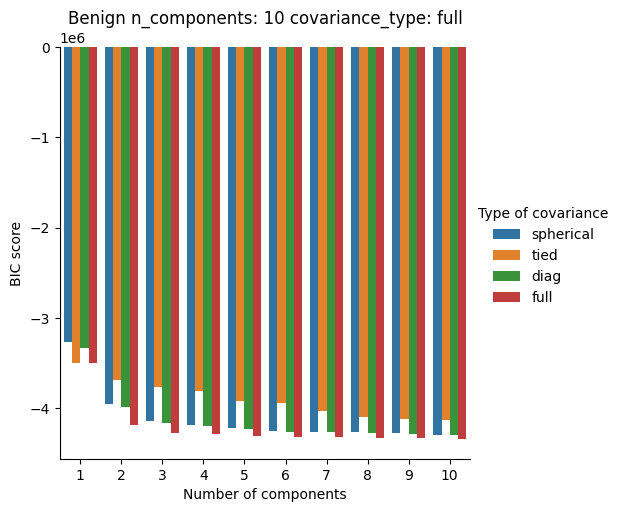

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


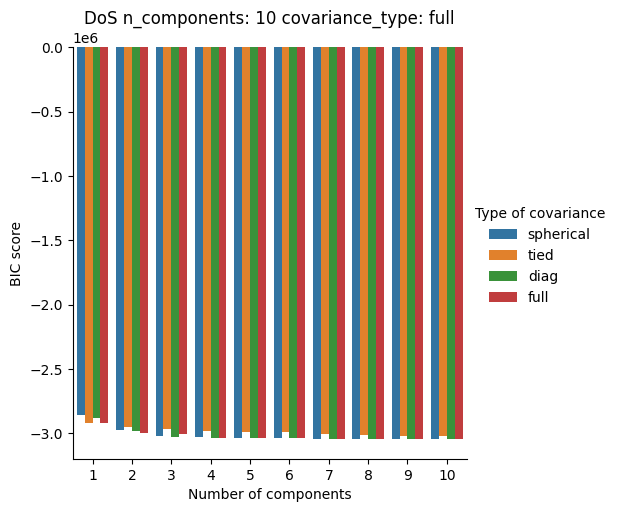

Tipo: 5 = Web
Melhor modelo: n_componentes: 10 covariance_type: spherical


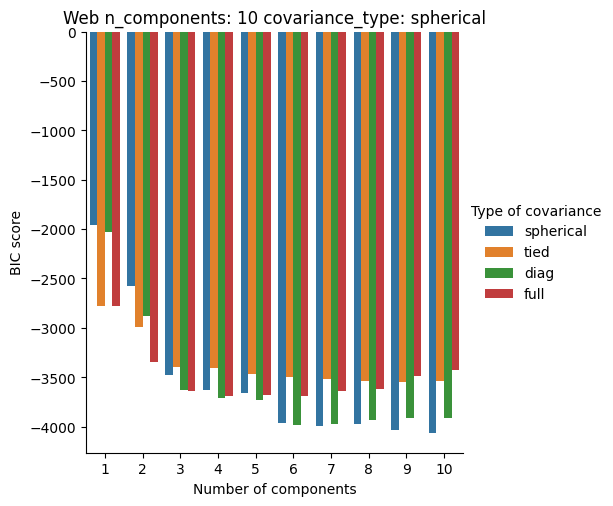

,0,1,2,3,4,5
0,23.069661,13.093857,-29.288464,NaN,NaN,11.269037
1,21.433503,12.322650,-20.970527,NaN,NaN,9.522972
2,13.878748,22.225331,-19.949032,NaN,NaN,7.227539
3,9.080769,14.287541,-8.775440,NaN,NaN,2.500343
4,22.250880,11.855657,-32.250811,NaN,NaN,9.542321
...,...,...,...,...,...,...
649942,15.618906,22.365622,-15.988395,NaN,NaN,6.833974
649943,22.156854,11.645662,-31.812258,NaN,NaN,9.371279
649944,22.230269,11.778190,-32.065574,NaN,NaN,9.477030
649945,-18.174871,-12.908542,9.630569,NaN,NaN,-3.623387


3_5


Label
0    808919
1    514148
2    329224
4    183163
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


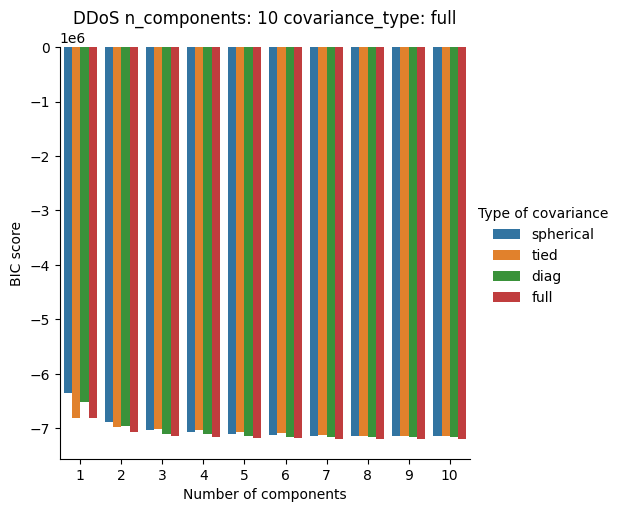

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


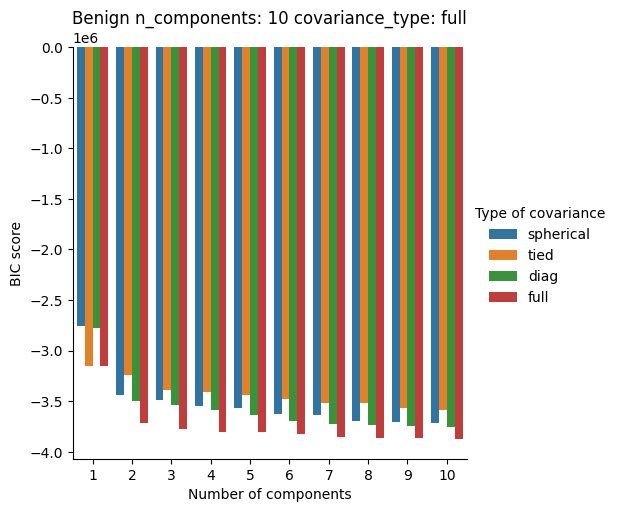

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


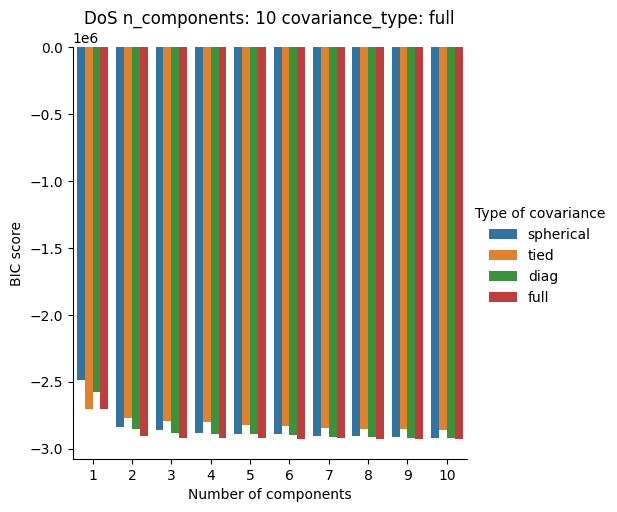

Tipo: 4 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


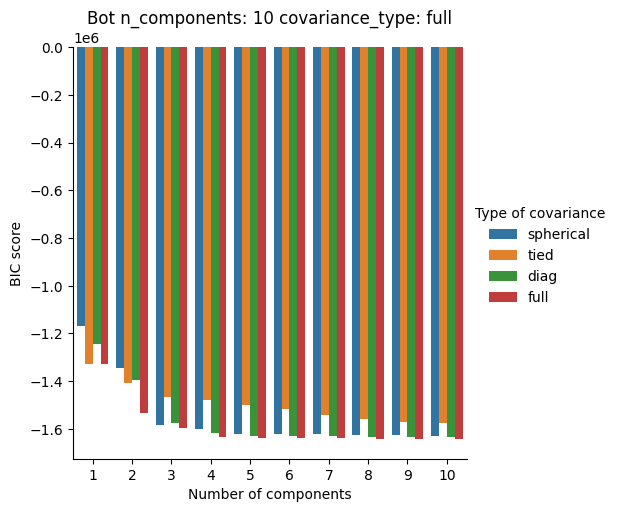

,0,1,2,3,4,5
0,23.022057,5.230900,-27.193516,NaN,4.095667,NaN
1,22.293026,5.131990,-24.924814,NaN,2.947396,NaN
2,-30.212497,17.888697,-48.512968,NaN,14.032631,NaN
3,12.971617,13.112585,-18.474994,NaN,5.786963,NaN
4,20.499038,8.639436,-20.937229,NaN,4.196899,NaN
...,...,...,...,...,...,...
649942,-35.719174,20.881270,-54.428132,NaN,4.603127,NaN
649943,21.229622,12.154535,-22.115455,NaN,4.062093,NaN
649944,21.313987,11.440897,-21.833405,NaN,4.082009,NaN
649945,-667.655765,3.853748,8.405248,NaN,-36.047403,NaN


4_5


Label
0    808919
1    514148
2    329224
3    243806
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


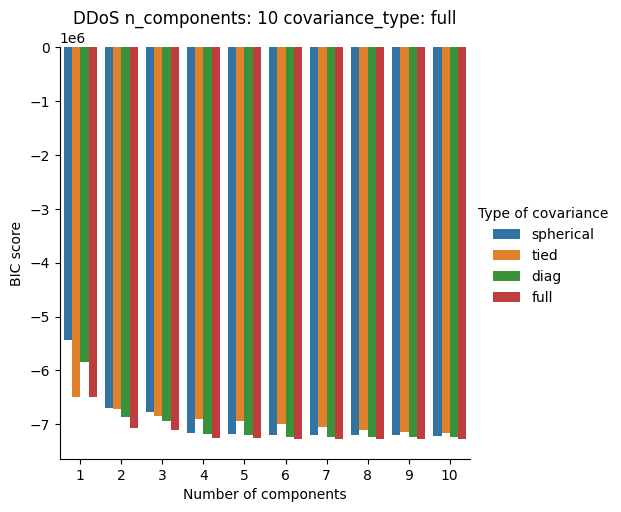

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


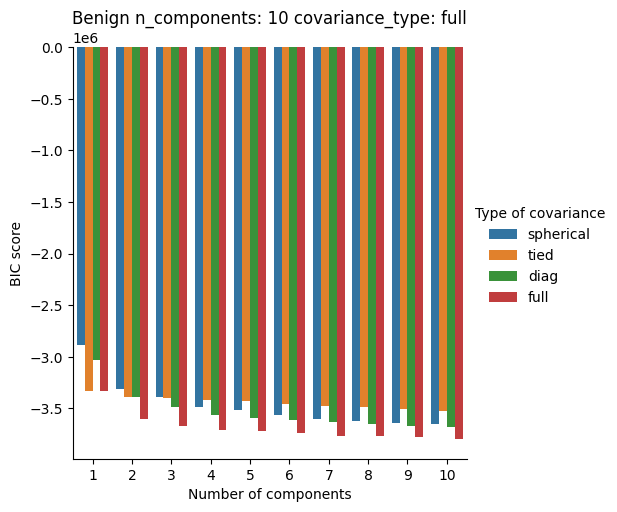

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


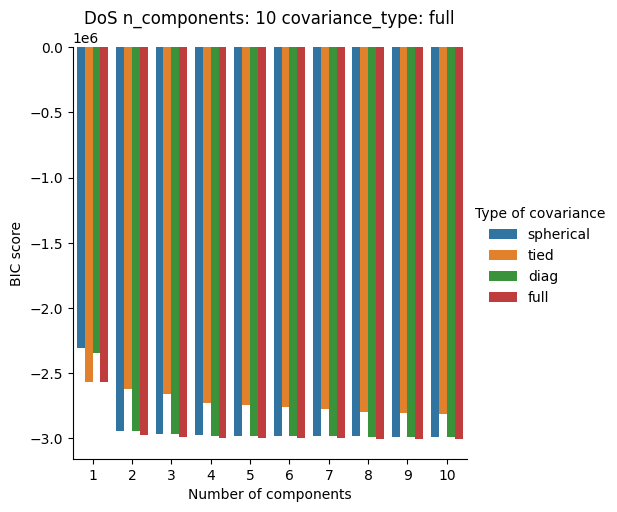

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 10 covariance_type: full


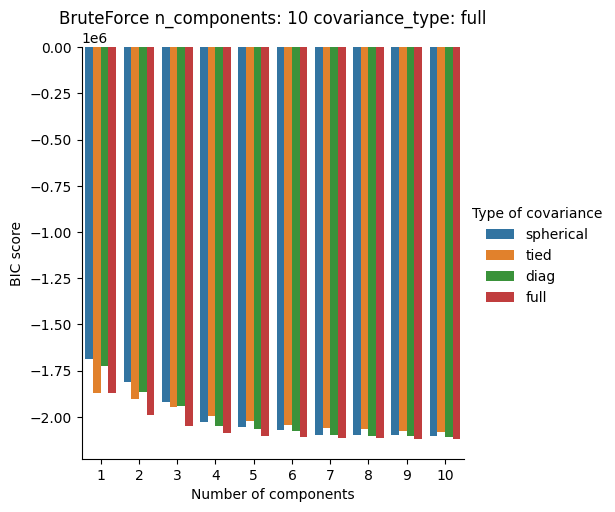

,0,1,2,3,4,5
0,22.964225,11.136106,-16.430691,-2990.318608,NaN,NaN
1,22.626210,11.043650,-19.386906,-2943.219322,NaN,NaN
2,-11.763408,15.379407,-14.547360,-1521.259010,NaN,NaN
3,5.442197,15.650772,-18.111966,-1761.275501,NaN,NaN
4,21.689950,8.838924,-20.480118,-2867.222779,NaN,NaN
...,...,...,...,...,...,...
649942,-12.665145,20.874495,-17.025245,-1626.383849,NaN,NaN
649943,21.117946,7.300443,-20.295181,-2891.874859,NaN,NaN
649944,21.592176,8.297225,-20.425675,-2878.058547,NaN,NaN
649945,-958.883913,-25.877930,-112.652178,22.049818,NaN,NaN


In [4]:
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import os

exp_train = []
exp_test = []
y_true_all_exp = []
cand_ths_all_exp = []

def gmm_bic_score(estimator, X):
    """Callable to pass to GridSearchCV that will use the BIC score."""
    # Make it negative since GridSearchCV expects a score to maximize
    return -estimator.bic(X)


param_grid = {
    "n_components": range(1, 11),
    "covariance_type": ["spherical", "tied", "diag", "full"],
    "random_state": [123],
}

for z in range(len(filenames)):
    train_encoded_df = pd.read_csv(f'train_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_2_hidden_{filenames[z]}_hidden.csv')
    test_encoded_df = pd.read_csv(f'test_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_2_hidden_{filenames[z]}_hidden.csv')
    print(filenames[z])
    hidden_classes = list(map(int, filenames[z].split('_'))) # Classes ocultas do treinamento
    for i in range(len(labels_str)):
        train_encoded_df['Label'] = train_encoded_df['Label'].replace(labels_str[i],i)
        test_encoded_df['Label'] = test_encoded_df['Label'].replace(labels_str[i],i)

    display(train_encoded_df['Label'].value_counts())
    if f'train_{filenames[z]}_GMM_BIC_1_10_scores.csv' not in os.listdir():
        
        gmms = []
        
        for i in range(len(labels_str)):
            if i not in hidden_classes:
                print(f'Tipo: {i} = {labels_str[i]}')
                grid_search = GridSearchCV(
                    GaussianMixture(), param_grid=param_grid, scoring=gmm_bic_score
                )
                grid_search.fit(train_encoded_df[train_encoded_df['Label'] == i].drop(columns=['Label']).to_numpy())
                print(f"Melhor modelo: n_componentes: {grid_search.best_params_['n_components']} covariance_type: {grid_search.best_params_['covariance_type']}")
                gmms.append(grid_search.best_estimator_)
                df = pd.DataFrame(grid_search.cv_results_)[
                    ["param_n_components", "param_covariance_type", "mean_test_score"]
                ]
                df["mean_test_score"] = -df["mean_test_score"]
                df = df.rename(
                    columns={
                        "param_n_components": "Number of components",
                        "param_covariance_type": "Type of covariance",
                        "mean_test_score": "BIC score",
                    }
                )
                df.sort_values(by="BIC score").head()
                sns.catplot(
                    data=df,
                    kind="bar",
                    x="Number of components",
                    y="BIC score",
                    hue="Type of covariance",
                    
                ).set(title = f"{labels_str[i]} n_components: {grid_search.best_params_['n_components']} covariance_type: {grid_search.best_params_['covariance_type']}")
                plt.show()
                # plt.savefig(f'class_{i}_train_{filenames[z]}_GMM_BIC_1_10_scores.png')
            else:
                gmms.append(None)
        
        # scores = []
        # for i, row in train_encoded_df.drop(columns=['Label']).iterrows():
        #     max_dist = -np.inf
        #     pred = -1
        #     scores.append([])
        #     for j in range(len(labels_str)):
        #         if j not in hidden_classes:
        #             inside = False
        #             max = -np.inf
        #             # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
        #             score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
        #             scores[i].append(score)
        #         else:
        #             scores[i].append(np.nan)
        
        
        # display(pd.DataFrame(scores))
        # exp_train.append(scores)
        #pd.DataFrame(scores).to_csv(f'train_{filenames[z]}_GMM_BIC_1_10_scores.csv',index=False)
        scores = []
        for i, row in test_encoded_df.drop(columns=['Label']).iterrows():
            max_dist = -np.inf
            pred = -1
            scores.append([])
            for j in range(len(labels_str)):
                if j not in hidden_classes:
                    inside = False
                    max = -np.inf
                    # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
                    score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
                    scores[i].append(score)
                else:
                    scores[i].append(np.nan)
        
        
        display(pd.DataFrame(scores))
        exp_test.append(scores)
        pd.DataFrame(scores).to_csv(f'test_{filenames[z]}_GMM_BIC_1_10_scores.csv', index=False)

In [6]:
ths = [0, 5, 10, 15, 20, 25, 30]
output= []
for i in range(len(exp_val)):
    hidden_classes = list(map(int, filenames[i].split('_'))) # Classes ocultas do treinamento
    for th in ths:
        y_pred = []
        for j in range(len(exp_val[i])):
            # print(exp[i][j])
            m = np.nanmax(exp_val[i][j]).max()
            # print(m)
            if m > th:
                y_pred.append(exp_val[i][j].index(m))
            else:
                y_pred.append(-1)
        # print(y_pred[:10])

        cm, cm_porcento = matriz_conf(y_true_all_exp[i], y_pred, list(range(len(labels_str))) + [-1])
        print(f'th = {th} hidden = {filenames[i]}')
        display(cm)
        tp = cm[-1][hidden_classes].sum()
        fp = cm[-1].sum() - tp
        fn = cm.iloc[hidden_classes].values.sum() - tp
        tn = cm.drop(columns=[-1]).values.sum() - fn

        acc = (tp+tn)/(tp+fp+tn+fn)
        recall = tp/(tp+fn)
        precision = tp/(tp+fp)
        if precision == 0 or recall == 0:
            f1 = 0
        else:
            f1 = 2*precision*recall/(precision+recall)

        print(f'hidden: {filenames[i]} th: {th} acc:{acc} recall:{recall} precision:{precision} f1:{f1}')
        output.append([filenames[i], th, acc, recall, precision, f1])

pd.DataFrame(output, columns=['hidden', 'th', 'acc', 'recall', 'precision', 'f1']).to_csv('output.csv')

[0, 1, 2, 3, 4, 5, 6, -1]
th = 0 hidden = 0_2


,0,1,2,3,4,5,6,-1
0,0,118191,0,0,10924,63825,23,9266
1,0,117165,0,52,691,9478,1133,17
2,0,73096,0,27472,0,596,390,3134
3,0,0,0,60931,0,0,0,20
4,0,1161,0,0,44551,54,24,0
5,0,17364,0,12,142,7999,160,25
6,0,3,0,0,10,4,129,2
-1,0,0,0,0,0,0,0,0


hidden: 0_2 th: 0 acc:0.48141165121011753 recall:0.04040180244170248 precision:0.9948652118100129 f1:0.07765020461455127
[0, 1, 2, 3, 4, 5, 6, -1]
th = 5 hidden = 0_2


,0,1,2,3,4,5,6,-1
0,0,118191,0,0,10924,49392,23,23699
1,0,117165,0,52,691,9429,1128,71
2,0,73096,0,27244,0,565,389,3394
3,0,0,0,60931,0,0,0,20
4,0,1161,0,0,44551,54,24,0
5,0,17364,0,12,142,7997,136,51
6,0,3,0,0,10,4,129,2
-1,0,0,0,0,0,0,0,0


hidden: 0_2 th: 5 acc:0.5071367710951968 recall:0.08827468012524559 precision:0.9947130741271065 f1:0.16215876512027388
[0, 1, 2, 3, 4, 5, 6, -1]
th = 10 hidden = 0_2


...

hidden: 5_6 th: 20 acc:0.9167758131412356 recall:0.050328820116054156 precision:0.05414741748865859 f1:0.052168334101890645
[0, 1, 2, 3, 4, 5, 6, -1]
th = 25 hidden = 5_6


,0,1,2,3,4,5,6,-1
0,196227,0,0,0,0,0,0,6002
1,4,0,0,0,0,0,0,128532
2,0,0,0,0,0,0,0,104688
3,0,0,0,0,0,0,0,60951
4,0,0,0,0,0,0,0,45790
5,1,0,0,0,0,0,0,25701
6,0,0,0,0,0,0,0,148
-1,0,0,0,0,0,0,0,0


hidden: 5_6 th: 25 acc:0.3909556301976607 recall:0.9999613152804642 precision:0.06952169375921165 f1:0.1300048785149197
[0, 1, 2, 3, 4, 5, 6, -1]
th = 30 hidden = 5_6


,0,1,2,3,4,5,6,-1
0,0,0,0,0,0,0,0,202229
1,0,0,0,0,0,0,0,128536
2,0,0,0,0,0,0,0,104688
3,0,0,0,0,0,0,0,60951
4,0,0,0,0,0,0,0,45790
5,0,0,0,0,0,0,0,25702
6,0,0,0,0,0,0,0,148
-1,0,0,0,0,0,0,0,0


hidden: 5_6 th: 30 acc:0.045507038187182686 recall:1.0 precision:0.045507038187182686 f1:0.08705257167103894


In [5]:
exp_train = []
exp_val = []
y_true_all_exp = []
for z in range(len(filenames)):
    train_encoded_df = pd.read_csv(f'train_encoded_CADE_cod_joined_attacks_pick_class_not_squared_normalized_{filenames[z]}_hidden.csv')
    val_encoded_df = pd.read_csv(f'val_encoded_CADE_cod_joined_attacks_pick_class_not_squared_normalized_{filenames[z]}_hidden.csv')
    print(filenames[z])
    hidden_classes = list(map(int, filenames[z].split('_'))) # Classes ocultas do treinamento
    for i in range(len(labels_str)):
        train_encoded_df['Label'] = train_encoded_df['Label'].replace(labels_str[i],i)
        val_encoded_df['Label'] = val_encoded_df['Label'].replace(labels_str[i],i)

    display(train_encoded_df['Label'].value_counts())
    y_true_all_exp.append(val_encoded_df['Label'].values.tolist())
    
    
    gmms = []
    
    n_components = 2
    for i in range(len(labels_str)):
        if i not in hidden_classes:
            print(f'Tipo: {i} = {labels_str[i]}')
            gmms.append(GaussianMixture(n_components=n_components, covariance_type='full', random_state=123))
            gmms[i].fit(train_encoded_df[train_encoded_df['Label'] == i].drop(columns=['Label']).to_numpy())
        else:
            gmms.append(None)
    
    scores = []
    for i, row in train_encoded_df.drop(columns=['Label']).iterrows():
        max_dist = -np.inf
        pred = -1
        scores.append([])
        for j in range(len(labels_str)):
            if j not in hidden_classes:
                inside = False
                max = -np.inf
                # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
                score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
                scores[i].append(score)
            else:
                scores[i].append(np.nan)
    
    
    display(pd.DataFrame(scores))
    exp_train.append(scores)

    scores = []
    for i, row in val_encoded_df.drop(columns=['Label']).iterrows():
        max_dist = -np.inf
        pred = -1
        scores.append([])
        for j in range(len(labels_str)):
            if j not in hidden_classes:
                inside = False
                max = -np.inf
                # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
                score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
                scores[i].append(score)
            else:
                scores[i].append(np.nan)
    
    
    display(pd.DataFrame(scores))
    exp_val.append(scores)

0_2


Label
1    514148
3    243804
4    183163
5    102810
6       595
Name: count, dtype: int64

Tipo: 1 = Benign
Tipo: 3 = BruteForce
Tipo: 4 = Bot
Tipo: 5 = Infilteration
Tipo: 6 = Web


,0,1,2,3,4,5,6
0,NaN,27.564294,NaN,-797.477373,12.146782,27.209738,19.659786
1,NaN,26.904323,NaN,-714.436985,6.102504,25.682954,16.632570
2,NaN,20.305266,NaN,-940.190906,0.224900,22.080893,18.093917
3,NaN,-11.913646,NaN,29.819001,-374.929624,-12.451787,-49.456951
4,NaN,27.321499,NaN,-736.555340,10.208416,26.036503,19.180810
...,...,...,...,...,...,...,...
1044515,NaN,27.559497,NaN,-793.766699,12.064264,27.202538,19.595150
1044516,NaN,17.487659,NaN,-1665.242829,28.587985,11.870732,21.465421
1044517,NaN,26.907709,NaN,-717.387170,5.992486,25.720060,16.620932
1044518,NaN,19.195741,NaN,-905.466616,24.543306,18.599718,20.945324


,0,1,2,3,4,5,6
0,NaN,18.903386,NaN,-1171.216563,-7.400866,20.852505,18.768581
1,NaN,25.262864,NaN,-753.563446,10.959395,23.263549,18.853967
2,NaN,19.676562,NaN,-1057.425070,2.081212,23.572086,18.976478
3,NaN,18.869584,NaN,-1126.807832,-5.390082,20.805330,18.720781
4,NaN,7.305324,NaN,-883.699048,-143.576613,5.527423,-0.486794
...,...,...,...,...,...,...,...
568039,NaN,19.460875,NaN,-764.222244,21.410627,20.213949,20.261940
568040,NaN,-11.523838,NaN,29.779719,-369.332178,-12.066311,-48.929301
568041,NaN,27.502091,NaN,-811.856188,12.020518,27.194765,19.583646
568042,NaN,21.073977,NaN,-1003.805319,4.588906,24.315200,18.942859


...

5_6


Label
0    808918
1    514148
2    418752
3    243804
4    183163
Name: count, dtype: int64

Tipo: 0 = DDoS
Tipo: 1 = Benign
Tipo: 2 = DoS
Tipo: 3 = BruteForce
Tipo: 4 = Bot


,0,1,2,3,4,5,6
0,-15.660200,27.268890,-919.681908,-1994.079396,-2.070593,NaN,NaN
1,28.817727,8.493349,-1795.753844,-1464.781964,-36.030858,NaN,NaN
2,-13.750229,26.728831,-940.117891,-2067.526746,-6.609528,NaN,NaN
3,0.039293,25.558756,-941.424430,-2032.250771,8.298305,NaN,NaN
4,28.663615,8.637278,-1762.271807,-1452.563299,-26.898103,NaN,NaN
...,...,...,...,...,...,...,...
2168780,-3.627336,13.801656,-1016.779849,-2724.464698,20.096559,NaN,NaN
2168781,-6320.270221,-56.919110,25.111620,8.395532,-11035.320849,NaN,NaN
2168782,-15.774350,27.271009,-921.427641,-1994.975425,-2.133520,NaN,NaN
2168783,29.230899,8.676093,-1763.678596,-1442.679232,-31.975556,NaN,NaN


,0,1,2,3,4,5,6
0,28.692106,8.683881,-1777.618327,-1470.632837,-30.392585,NaN,NaN
1,29.230576,8.675954,-1763.676468,-1442.668824,-31.980870,NaN,NaN
2,1.255813,26.090826,-923.640375,-2021.038558,9.145501,NaN,NaN
3,28.791260,8.662454,-1780.063015,-1471.405540,-30.364029,NaN,NaN
4,28.671889,8.644436,-1761.859696,-1452.543900,-26.871570,NaN,NaN
...,...,...,...,...,...,...,...
568039,-6320.168603,-56.917905,25.111622,8.392676,-11035.197520,NaN,NaN
568040,-4155.415765,-144.138444,-7.495747,25.674202,-7569.808503,NaN,NaN
568041,-15.922505,27.267798,-920.952606,-1995.045048,-2.267705,NaN,NaN
568042,0.670610,26.007085,-921.877006,-2027.463687,8.473907,NaN,NaN


In [ ]:
ths = [0, 5, 10, 15, 20, 25, 30]
output= []
for i in range(len(exp_val)):
    hidden_classes = list(map(int, filenames[i].split('_'))) # Classes ocultas do treinamento
    for th in ths:
        y_pred = []
        for j in range(len(exp_val[i])):
            # print(exp[i][j])
            m = np.nanmax(exp_val[i][j]).max()
            # print(m)
            if m > th:
                y_pred.append(exp_val[i][j].index(m))
            else:
                y_pred.append(-1)
        # print(y_pred[:10])

        cm, cm_porcento = matriz_conf(y_true_all_exp[i], y_pred, list(range(len(labels_str))) + [-1])
        print(f'th = {th} hidden = {filenames[i]}')
        display(cm)
        tp = cm[-1][hidden_classes].sum()
        fp = cm[-1].sum() - tp
        fn = cm.iloc[hidden_classes].values.sum() - tp
        tn = cm.drop(columns=[-1]).values.sum() - fn

        acc = (tp+tn)/(tp+fp+tn+fn)
        recall = tp/(tp+fn)
        precision = tp/(tp+fp)
        if precision == 0 or recall == 0:
            f1 = 0
        else:
            f1 = 2*precision*recall/(precision+recall)

        print(f'hidden: {filenames[i]} th: {th} acc:{acc} recall:{recall} precision:{precision} f1:{f1}')
        output.append([filenames[i], th, acc, recall, precision, f1])

pd.DataFrame(output, columns=['hidden', 'th', 'acc', 'recall', 'precision', 'f1']).to_csv('output2.csv')

[0, 1, 2, 3, 4, 5, 6, -1]
th = 0 hidden = 0_2


,0,1,2,3,4,5,6,-1
0,0,109894,0,0,1,48257,43745,332
1,0,101437,0,52,1813,22259,2942,33
2,0,3029,0,27483,62486,8568,473,2649
3,0,1,0,60931,0,0,0,19
4,0,20,0,0,45569,21,180,0
5,0,13881,0,12,512,10937,348,12
6,0,3,0,0,6,1,133,5
-1,0,0,0,0,0,0,0,0


hidden: 0_2 th: 0 acc:0.4648213870756491 recall:0.00971272363538025 precision:0.9773770491803279 f1:0.01923430558736898
[0, 1, 2, 3, 4, 5, 6, -1]
th = 5 hidden = 0_2


,0,1,2,3,4,5,6,-1
0,0,109842,0,0,1,48257,43745,384
1,0,101429,0,52,1813,22240,2941,61
2,0,2810,0,27246,62486,8296,473,3377
3,0,0,0,60931,0,0,0,20
4,0,19,0,0,45569,21,180,1
5,0,13853,0,12,512,10935,348,42
6,0,3,0,0,6,1,133,5
-1,0,0,0,0,0,0,0,0


hidden: 0_2 th: 5 acc:0.4660888945222553 recall:0.012254127337358308 precision:0.9668380462724936 f1:0.02420151412291229
[0, 1, 2, 3, 4, 5, 6, -1]
th = 10 hidden = 0_2


...

hidden: 5_6 th: 20 acc:0.9274844906380492 recall:0.11063829787234042 precision:0.13578957363973032 f1:0.12193042291950885
[0, 1, 2, 3, 4, 5, 6, -1]
th = 25 hidden = 5_6


,0,1,2,3,4,5,6,-1
0,196280,1,0,0,0,0,0,5948
1,6,108175,4,0,14,0,0,20337
2,0,0,70882,197,0,0,0,33609
3,0,0,0,37818,0,0,0,23133
4,0,1,0,0,42130,0,0,3659
5,1,16898,1,0,0,0,0,8802
6,0,22,0,0,5,0,0,121
-1,0,0,0,0,0,0,0,0


hidden: 5_6 th: 25 acc:0.8175968762983149 recall:0.345183752417795 precision:0.09332803397169723 f1:0.14693023983401807
[0, 1, 2, 3, 4, 5, 6, -1]
th = 30 hidden = 5_6


,0,1,2,3,4,5,6,-1
0,0,0,0,0,0,0,0,202229
1,0,0,0,0,0,0,0,128536
2,0,0,0,0,0,0,0,104688
3,0,0,0,0,0,0,0,60951
4,0,0,0,0,0,0,0,45790
5,0,0,0,0,0,0,0,25702
6,0,0,0,0,0,0,0,148
-1,0,0,0,0,0,0,0,0


hidden: 5_6 th: 30 acc:0.045507038187182686 recall:1.0 precision:0.045507038187182686 f1:0.08705257167103894


In [43]:
ths = [0, 5, 10, 15, 20, 25, 30]

for i in range(len(exp_val)):
    for th in ths:
        y_pred = []
        for j in range(len(exp_val[i])):
            # print(exp[i][j])
            m = np.nanmax(exp_val[i][j]).max()
            # print(m)
            if m > th:
                y_pred.append(exp_val[i][j].index(m))
            else:
                y_pred.append(-1)
        # print(y_pred[:10])

        cm, cm_porcento = matriz_conf(y_true_all_exp[i], y_pred, list(range(len(labels_str))) + [-1])
        print(f'th = {th} hidden = {filenames[i]}')
        display(cm)
        tp = cm[-1][filenames[i]]
        fp = cm[-1].sum() - tp
        fn = cm.iloc[filenames[i]].sum() - tp
        tn = cm.drop(columns=[-1]).values.sum() - fn

        acc = (tp+tn)/(tp+fp+tn+fn)
        recall = tp/(tp+fn)
        precision = tp/(tp+fp)
        if precision == 0 or recall == 0:
            f1 = 0
        else:
            f1 = 2*precision*recall/(precision+recall)


        print(f'th: {th} hidden: {filenames[i]} acc:{acc} recall:{recall} precision:{precision} f1:{f1}')

[0, 1, 2, 3, 4, 5, 6, -1]
th = 0 hidden = 0


,0,1,2,3,4,5,6,-1
0,0,155875,0,0,45908,46,14,386
1,0,102432,19,53,4210,20677,1080,65
2,0,593,89645,14448,0,0,0,2
3,0,1,2732,58216,0,0,0,2
4,0,133,0,0,45596,42,19,0
5,0,14852,5,11,597,9980,139,118
6,0,1,0,0,11,7,128,1
-1,0,0,0,0,0,0,0,0


th: 0 hidden: 0 acc:0.6443391709092957 recall:0.0019087272349663006 precision:0.6724738675958188 f1:0.003806649803010804
[0, 1, 2, 3, 4, 5, 6, -1]
th = 5 hidden = 0


,0,1,2,3,4,5,6,-1
0,0,155875,0,0,45908,46,4,396
1,0,102406,18,53,4210,20647,1074,128
2,0,455,89645,14448,0,0,0,140
3,0,1,2732,58216,0,0,0,2
4,0,132,0,0,45596,42,19,1
5,0,14837,5,11,597,9931,120,201
6,0,1,0,0,11,7,128,1
-1,0,0,0,0,0,0,0,0


th: 5 hidden: 0 acc:0.6438550534817725 recall:0.001958176127063873 precision:0.45569620253164556 f1:0.00389959526927887
[0, 1, 2, 3, 4, 5, 6, -1]
th = 10 hidden = 0


...

th: 20 hidden: 6 acc:0.9206117835942286 recall:0.8378378378378378 precision:0.0027436056288167093 f1:0.005469301340860974
[0, 1, 2, 3, 4, 5, 6, -1]
th = 25 hidden = 6


,0,1,2,3,4,5,6,-1
0,200503,3,0,0,0,0,0,1723
1,110,70824,4,0,12,513,0,57073
2,0,0,89676,11550,0,0,0,3462
3,0,0,3438,57215,0,0,0,298
4,7,0,0,0,42204,0,0,3579
5,13,10958,1,0,5,143,0,14582
6,11,0,0,0,8,0,0,129
-1,0,0,0,0,0,0,0,0


th: 25 hidden: 6 acc:0.8578701649872194 recall:0.8716216216216216 precision:0.0015956262523810702 f1:0.0031854211423068377
[0, 1, 2, 3, 4, 5, 6, -1]
th = 30 hidden = 6


,0,1,2,3,4,5,6,-1
0,193262,0,0,0,0,0,0,8967
1,14,0,3,0,5,0,0,128514
2,0,0,70466,0,0,0,0,34222
3,0,0,0,26129,0,0,0,34822
4,0,0,0,0,42176,0,0,3614
5,1,0,1,0,2,0,0,25698
6,0,0,0,0,6,0,0,142
-1,0,0,0,0,0,0,0,0


th: 30 hidden: 6 acc:0.584815612875059 recall:0.9594594594594594 precision:0.0006017484606681103 f1:0.0012027425919102857


In [55]:
exp_train = []
exp_val = []
y_true_all_exp = []
cand_ths_all_exp = []
for z in range(len(filenames)):
    train_encoded_df = pd.read_csv(f'train_encoded_CADE_cod_joined_attacks_pick_class_not_squared_normalized_{filenames[z]}_hidden.csv')
    val_encoded_df = pd.read_csv(f'val_encoded_CADE_cod_joined_attacks_pick_class_not_squared_normalized_{filenames[z]}_hidden.csv')
    print(filenames[z])
    hidden_classes = [filenames[z]] # Classes ocultas do treinamento
    for i in range(len(labels_str)):
        train_encoded_df['Label'] = train_encoded_df['Label'].replace(labels_str[i],i)
        val_encoded_df['Label'] = val_encoded_df['Label'].replace(labels_str[i],i)

    display(train_encoded_df['Label'].value_counts())
    y_true_all_exp.append(val_encoded_df['Label'].values.tolist())
    
    gmms = []
    
    n_components = 3
    for i in range(len(labels_str)):
        if i not in hidden_classes:
            print(f'Tipo: {i} = {labels_str[i]}')
            gmms.append(GaussianMixture(n_components=n_components, covariance_type='full', random_state=123))
            gmms[i].fit(train_encoded_df[train_encoded_df['Label'] == i].drop(columns=['Label']).to_numpy())
        else:
            gmms.append(None)
    
    scores = []
    for i, row in train_encoded_df.drop(columns=['Label']).iterrows():
        max_dist = -np.inf
        pred = -1
        scores.append([])
        for j in range(len(labels_str)):
            if j not in hidden_classes:
                inside = False
                max = -np.inf
                # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
                score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
                scores[i].append(score)
            else:
                scores[i].append(np.nan)
    
    
    display(pd.DataFrame(scores))
    exp_train.append(scores)

    cand_ths_all_exp.append([])
    for i in range(len(labels_str)):
        idx = train_encoded_df[train_encoded_df['Label'] == i].index.values
        cand_ths_all_exp[z].append(pd.DataFrame(exp_train[z]).loc[idx][i].mean())

    scores = []
    for i, row in val_encoded_df.drop(columns=['Label']).iterrows():
        max_dist = -np.inf
        pred = -1
        scores.append([])
        for j in range(len(labels_str)):
            if j not in hidden_classes:
                inside = False
                max = -np.inf
                # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
                score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
                scores[i].append(score)
            else:
                scores[i].append(np.nan)
    
    
    display(pd.DataFrame(scores))
    exp_val.append(scores)

0


Label
1    514148
2    418752
3    243804
4    183163
5    102810
6       595
Name: count, dtype: int64

Tipo: 1 = Benign
Tipo: 2 = DoS
Tipo: 3 = BruteForce
Tipo: 4 = Bot
Tipo: 5 = Infilteration
Tipo: 6 = Web


,0,1,2,3,4,5,6
0,NaN,28.756235,-644.149489,-3266.824007,-49.603573,28.005905,10.890285
1,NaN,27.122667,-532.102601,-2911.145401,-76.630096,26.691768,12.732034
2,NaN,18.200171,-887.483811,-4375.193475,6.910350,17.558317,14.848108
3,NaN,1.096809,31.813719,32.283297,-800.854149,3.638049,-110.484628
4,NaN,-4.346050,20.270154,33.799551,-1081.182481,-1.240643,-129.720621
...,...,...,...,...,...,...,...
1463267,NaN,8.258706,31.123986,30.591246,-404.542690,9.643594,-82.436113
1463268,NaN,17.349398,-744.632655,-4457.638962,24.387066,16.283098,13.336248
1463269,NaN,8.409002,34.468751,28.420421,-382.605870,9.854319,-90.466229
1463270,NaN,28.627320,-684.061949,-3512.670948,-45.423635,28.400642,12.232673


,0,1,2,3,4,5,6
0,NaN,17.516120,-1283.093252,-6708.096119,-20.612155,17.136780,-31.792133
1,NaN,17.260901,-382.596311,-1862.481351,3.339425,16.263475,16.615616
2,NaN,18.189655,-1016.354763,-5157.599521,8.099254,20.901402,1.439487
3,NaN,17.474833,-1356.497924,-7065.079123,-18.399551,17.156570,-27.540582
4,NaN,14.905092,-157.197043,-822.689587,-131.181929,14.704955,-10.382310
...,...,...,...,...,...,...,...
568039,NaN,8.413463,34.470493,28.441349,-382.518411,9.857275,-90.447656
568040,NaN,-4.145092,20.533037,33.817542,-1070.051779,-1.149077,-127.145395
568041,NaN,28.703110,-686.272275,-3503.742037,-43.820213,28.413509,12.266946
568042,NaN,18.224281,-1048.968741,-5339.035521,9.433113,20.408795,-1.261750


...

6


Label
0    808918
1    514148
2    418752
3    243804
4    183163
5    102810
Name: count, dtype: int64

Tipo: 0 = DDoS
Tipo: 1 = Benign
Tipo: 2 = DoS
Tipo: 3 = BruteForce
Tipo: 4 = Bot
Tipo: 5 = Infilteration


,0,1,2,3,4,5,6
0,-2330.331597,27.825155,-273.699676,-3558.753875,-9.569248,26.708565,NaN
1,34.013969,8.051102,-126.547102,-1799.359938,-77.375004,7.386163,NaN
2,-2259.541833,26.013619,-232.007517,-3406.536792,-9.241586,24.727997,NaN
3,-1652.199644,18.479044,-158.580594,-2798.191994,-87.447806,16.497147,NaN
4,33.802520,7.824937,-127.662934,-1827.302568,-85.603288,7.838117,NaN
...,...,...,...,...,...,...,...
2271590,-97.060759,22.070476,-2204.979601,-15026.051475,23.027325,20.674929,NaN
2271591,-8970.965183,-32.652694,33.573435,12.687891,-1309.275083,-26.786864,NaN
2271592,-2625.498735,27.777210,-300.939545,-3800.192235,-10.239262,26.661317,NaN
2271593,34.200564,8.105956,-125.707054,-1802.448219,-81.273874,7.649624,NaN


,0,1,2,3,4,5,6
0,33.647155,7.487150,-126.379619,-1812.732353,-84.928621,7.791056,NaN
1,34.189924,8.073704,-125.938857,-1803.961996,-81.760202,7.623472,NaN
2,-2457.808146,19.379380,-207.554457,-3385.759527,-43.881957,20.729965,NaN
3,33.663232,7.540602,-126.405702,-1816.899566,-85.230858,7.857401,NaN
4,33.717970,7.831172,-127.726644,-1829.409883,-86.042297,7.844349,NaN
...,...,...,...,...,...,...,...
568039,-8970.251264,-32.643827,33.574176,12.685898,-1309.162392,-26.779948,NaN
568040,-17198.646243,-64.323854,10.434396,32.944967,-2860.492815,-40.736926,NaN
568041,-2547.814545,27.938639,-294.785952,-3745.004377,-9.915604,26.904284,NaN
568042,-2787.489275,19.500406,-232.883799,-3634.938044,-42.616825,21.774599,NaN


In [56]:
ths = [0, 5, 10, 15, 20, 25, 30]

for i in range(len(exp_val)):
    for th in ths:
        y_pred = []
        for j in range(len(exp_val[i])):
            # print(exp[i][j])
            m = np.nanmax(exp_val[i][j]).max()
            # print(m)
            if m > th:
                y_pred.append(exp_val[i][j].index(m))
            else:
                y_pred.append(-1)
        # print(y_pred[:10])

        cm, cm_porcento = matriz_conf(y_true_all_exp[i], y_pred, list(range(len(labels_str))) + [-1])
        print(f'th = {th} hidden = {filenames[i]}')
        display(cm)
        tp = cm[-1][filenames[i]]
        fp = cm[-1].sum() - tp
        fn = cm.iloc[filenames[i]].sum() - tp
        tn = cm.drop(columns=[-1]).values.sum() - fn

        acc = (tp+tn)/(tp+fp+tn+fn)
        recall = tp/(tp+fn)
        precision = tp/(tp+fp)
        if precision == 0 or recall == 0:
            f1 = 0
        else:
            f1 = 2*precision*recall/(precision+recall)


        print(f'th: {th} hidden: {filenames[i]} acc:{acc} recall:{recall} precision:{precision} f1:{f1}')

[0, 1, 2, 3, 4, 5, 6, -1]
th = 0 hidden = 0


,0,1,2,3,4,5,6,-1
0,0,155869,4,0,45940,16,0,400
1,0,107174,82,1,4455,16183,598,43
2,0,0,90255,14421,0,12,0,0
3,0,0,3208,57742,0,1,0,0
4,0,4,0,0,45593,135,58,0
5,0,15579,21,0,662,9203,157,80
6,0,18,0,0,11,5,113,1
-1,0,0,0,0,0,0,0,0


th: 0 hidden: 0 acc:0.6444764842160114 recall:0.001977955683902902 precision:0.7633587786259542 f1:0.003945687610047694
[0, 1, 2, 3, 4, 5, 6, -1]
th = 5 hidden = 0


,0,1,2,3,4,5,6,-1
0,0,155869,4,0,45940,15,0,401
1,0,107174,82,1,4455,16142,598,84
2,0,0,90255,14421,0,12,0,0
3,0,0,3207,57742,0,1,0,1
4,0,4,0,0,45593,135,58,0
5,0,15579,21,0,662,9111,156,173
6,0,18,0,0,11,3,113,3
-1,0,0,0,0,0,0,0,0


th: 5 hidden: 0 acc:0.6442370661427635 recall:0.0019829005731126594 precision:0.6057401812688822 f1:0.003952861388627391
[0, 1, 2, 3, 4, 5, 6, -1]
th = 10 hidden = 0


...

th: 20 hidden: 6 acc:0.934179394553943 recall:0.6959459459459459 precision:0.0027505541164846315 f1:0.005479452054794521
[0, 1, 2, 3, 4, 5, 6, -1]
th = 25 hidden = 6


,0,1,2,3,4,5,6,-1
0,200768,3,0,0,0,0,0,1458
1,533,70840,3,1,11,555,0,56593
2,0,0,84561,12735,0,0,0,7392
3,0,0,2822,57778,0,0,0,351
4,8,0,0,0,42199,0,0,3583
5,67,10953,1,0,5,159,0,14517
6,2,0,0,0,9,0,0,137
-1,0,0,0,0,0,0,0,0


th: 25 hidden: 6 acc:0.8522913717951426 recall:0.9256756756756757 precision:0.0016303507039068916 f1:0.003254968578861711
[0, 1, 2, 3, 4, 5, 6, -1]
th = 30 hidden = 6


,0,1,2,3,4,5,6,-1
0,198453,0,0,0,0,0,0,3776
1,87,0,3,0,9,0,0,128437
2,0,0,72012,10064,0,0,0,22612
3,0,0,0,54130,0,0,0,6821
4,5,0,0,0,42190,0,0,3595
5,10,0,1,0,5,0,0,25686
6,2,0,0,0,8,0,0,138
-1,0,0,0,0,0,0,0,0


th: 30 hidden: 6 acc:0.663869348149087 recall:0.9324324324324325 precision:0.0007222672912359668 f1:0.0014434165041079844
